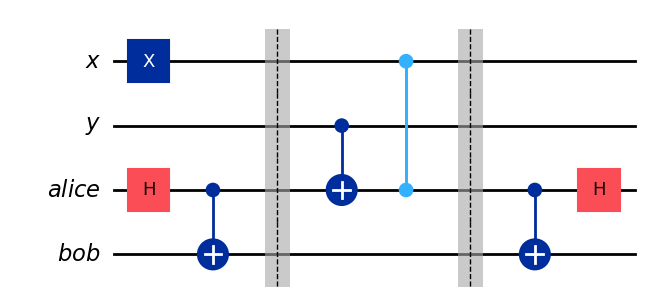

In [1]:
# https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/entanglement-in-action/superdense-coding

from qiskit import QuantumCircuit, QuantumRegister

# Classical input message variables
x = 1
y = 0

qc = QuantumCircuit(
    q_x := QuantumRegister(1, "x"),
    q_y := QuantumRegister(1, "y"),
    q_alice := QuantumRegister(1, "alice"),
    q_bob := QuantumRegister(1, "bob"),
)

# Initialize states |x> and |y> based on variables x and y
if x == 1:
    qc.x(q_x)
if y == 1:
    qc.x(q_y)

# Prepare Bell pair ('alice' and 'bob' qubits)
qc.h(q_alice)
qc.cx(q_alice, q_bob)
qc.barrier()

# Alice's operations controlled by named qubits |x> and |y>
qc.cx(q_y, q_alice)
qc.cz(q_x, q_alice)
qc.barrier()

# Bob's operations (Bell state decoding)
qc.cx(q_alice, q_bob)
qc.h(q_alice)

display(qc.draw(output="mpl"))

In [2]:
from qiskit.quantum_info import Statevector

state = Statevector.from_instruction(qc)
ideal_dist = state.probabilities_dict()

display(state.draw("latex"))

<IPython.core.display.Latex object>